In [ ]:
!pip install -q tensorflow tensorflow-addons tensorflow-io seaborn

import tensorflow as tf
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 29.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.16.1 requires typeguard<5,>=3, but you have typeguard 2.13.3 which is incompatible.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


2025-08-28 17:19:52.473545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756401592.667097      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756401592.721611      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Dataset Preparation

In [ ]:
import os, shutil

DATASET_TRAIN_VALID = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
DATASET_TEST = "/kaggle/input/new-plant-diseases-dataset/test/test"

BASE_DIR = "/kaggle/working/npd_hybrid"
shutil.rmtree(BASE_DIR, ignore_errors=True)
os.makedirs(BASE_DIR, exist_ok=True)

shutil.copytree(os.path.join(DATASET_TRAIN_VALID, "train"), os.path.join(BASE_DIR, "train"))
shutil.copytree(os.path.join(DATASET_TRAIN_VALID, "valid"), os.path.join(BASE_DIR, "valid"))


os.makedirs(os.path.join(BASE_DIR, "test"), exist_ok=True)
for f in os.listdir(DATASET_TEST):
    if f.lower().endswith((".jpg",".jpeg",".png")):
        shutil.copy(os.path.join(DATASET_TEST, f), os.path.join(BASE_DIR, "test", f))

print("✅ Dataset ready at:", BASE_DIR)
print("Train classes:", len(os.listdir(os.path.join(BASE_DIR, "train"))))
print("Valid classes:", len(os.listdir(os.path.join(BASE_DIR, "valid"))))
print("Test images:", len(os.listdir(os.path.join(BASE_DIR, "test"))))


✅ Dataset ready at: /kaggle/working/npd_hybrid
Train classes: 38
Valid classes: 38
Test images: 33


# Data Loading

In [ ]:
import os, tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
img_size = (299, 299)
batch_size = 64  

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"   
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "valid"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"   
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)
print("Number of classes:", num_classes)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

train_ds = (raw_train_ds
            .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds = (raw_val_ds
          .map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y), num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

test_dir = os.path.join(BASE_DIR, "test")
test_files = sorted([os.path.join(test_dir, f) 
                     for f in os.listdir(test_dir) 
                     if f.lower().endswith((".jpg",".jpeg",".png"))])
print("Found", len(test_files), "test images")

def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = img / 255.0
    return img

test_ds = tf.data.Dataset.from_tensor_slices(test_files)
test_ds = test_ds.map(lambda x: preprocess_image(x), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)


Found 70295 files belonging to 38 classes.


I0000 00:00:1756402354.049755      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 17572 files belonging to 38 classes.
Number of classes: 38
Found 33 test images


# Architecture

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Input, Dense, Dropout, Reshape, GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def transformer_encoder(inputs, num_heads, ff_dim):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(x, x)
    x = Add()([attention_output, inputs])
    x_norm = LayerNormalization(epsilon=1e-6)(x)
    ff_output = Dense(ff_dim, activation="relu")(x_norm)
    ff_output = Dense(inputs.shape[-1])(ff_output)
    x = Add()([ff_output, x])
    return x

def create_cnn_transformer(input_shape=(299,299,3), num_classes=38):
    cnn_base = InceptionV3(weights="imagenet", include_top=False, input_shape=input_shape)
    for layer in cnn_base.layers:
        layer.trainable = False
    
    inputs = Input(shape=input_shape)
    x = cnn_base(inputs)
    seq_len = x.shape[1] * x.shape[2]
    patch_dim = x.shape[-1]
    x = Reshape((seq_len, patch_dim))(x)
    x = transformer_encoder(x, num_heads=4, ff_dim=256)
    x = transformer_encoder(x, num_heads=4, ff_dim=256)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax", dtype="float32")(x)
    return Model(inputs, outputs, name="CNN_Transformer_Hybrid")

model = create_cnn_transformer(input_shape=(299,299,3), num_classes=num_classes)
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "CNN_Transformer_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 8, 8,      │ 21,802,784 │ input_layer_2[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 2048)  │          0 │ inception_v3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 2048)  │      4,096 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 2048)  │  8,393,728 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 2048)  │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 2048)  │      4,096 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 256)   │    524,544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 2048)  │    526,336 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 2048)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 2048)  │      4,096 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 2048)  │  8,393,728 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 2048)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 2048)  │      4,096 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 256)   │    524,544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 2048)  │    526,336 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 2048)  │          0 │ dense_3[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ add_3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 40,786,246 (155.59 MB)

 Trainable params: 18,983,462 (72.42 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []
for _, y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))
labels = np.array(labels)

class_weights_array = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
class_weights = {i : w for i, w in enumerate(class_weights_array)}
print("Class Weights ready")


Class Weights ready


# Training

In [ ]:
checkpoint1 = tf.keras.callbacks.ModelCheckpoint("best_stage1.keras", monitor="val_accuracy", save_best_only=True, mode="max")
lr1 = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history1 = model.fit(train_ds, epochs=20, validation_data=val_ds, class_weight=class_weights, callbacks=[checkpoint1, lr1], verbose=1)

model = tf.keras.models.load_model("best_stage1.keras")
for layer in model.layers: layer.trainable = True
model.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
checkpoint2 = tf.keras.callbacks.ModelCheckpoint("best_stage2.keras", monitor="val_accuracy", save_best_only=True, mode="max")
lr2 = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1)
history2 = model.fit(train_ds, epochs=10, validation_data=val_ds, class_weight=class_weights, callbacks=[checkpoint2, lr2], verbose=1)

model = tf.keras.models.load_model("best_stage2.keras")
model.compile(optimizer=Adam(5e-6), loss="categorical_crossentropy", metrics=["accuracy"])
checkpoint3 = tf.keras.callbacks.ModelCheckpoint("best_stage3.keras", monitor="val_accuracy", save_best_only=True, mode="max")
lr3 = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-8, verbose=1)
history3 = model.fit(train_ds, epochs=10, validation_data=val_ds, class_weight=class_weights, callbacks=[checkpoint3, lr3], verbose=1)

# Save final
final_model = tf.keras.models.load_model("best_stage3.keras")
final_model.save("cnn_transformer_hybrid_final.keras")
print("✅ Final model saved")


Epoch 1/20


I0000 00:00:1756403139.637066     108 service.cc:148] XLA service 0x7fba24002200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756403139.637748     108 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1756403145.123501     108 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756403163.150182     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1099/1099 ━━━━━━━━━━━━━━━━━━━━ 863s 745ms/step - accuracy: 0.7594 - loss: 0.8002 - val_accuracy: 0.9240 - val_loss: 0.2243 - learning_rate: 1.0000e-04
Epoch 2/20
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 794s 721ms/step - accuracy: 0.9271 - loss: 0.2170 - val_accuracy: 0.9336 - val_loss: 0.1997 - learning_rate: 1.0000e-04
Epoch 3/20
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 792s 719ms/step - accuracy: 0.9408 - loss: 0.1805 - val_accuracy: 0.9417 - val_loss: 0.1730 - learning_rate: 1.0000e-04
Epoch 4/20
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 789s 716ms/step - accuracy: 0.9474 - loss: 0.1627 - val_accuracy: 0.9368 - val_loss: 0.1954 - learning_rate: 1.0000e-04
Epoch 5/20
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 793s 720ms/step - accuracy: 0.9502 - loss: 0.1543 - val_accuracy: 0.9424 - val_loss: 0.1747 - learning_rate: 1.0000e-04
Epoch 6/20
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 792s 718ms/step - accuracy: 0.9553 - loss: 0.1348 - val_accuracy: 0.9458 - val_loss: 0.1710 - learning_rate: 1.0000e-04
Epoch 7/20
1099/1099 ━━━━━━━━━━━━━━━━━━

In [ ]:
from sklearn.metrics import classification_report

final_model = tf.keras.models.load_model("cnn_transformer_hybrid_final.keras")
val_loss, val_acc = final_model.evaluate(val_ds)
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

y_true, y_pred = [], []
for batch_x, batch_y in val_ds:
    preds = final_model.predict(batch_x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(batch_y.numpy(), axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


275/275 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.9870 - loss: 0.0363
Val Loss: 0.0367, Val Acc: 0.9870

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9960    0.9802    0.9880       504
                                 Apple___Black_rot     0.9940    0.9960    0.9950       497
                          Apple___Cedar_apple_rust     0.9977    0.9977    0.9977       440
                                   Apple___healthy     0.9861    0.9920    0.9891       502
                               Blueberry___healthy     0.9956    1.0000    0.9978       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       421
                 Cherry_(including_sour)___healthy     1.0000    0.9978    0.9989       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9719    0.9268    0.9488       410
                       Corn_(maize)

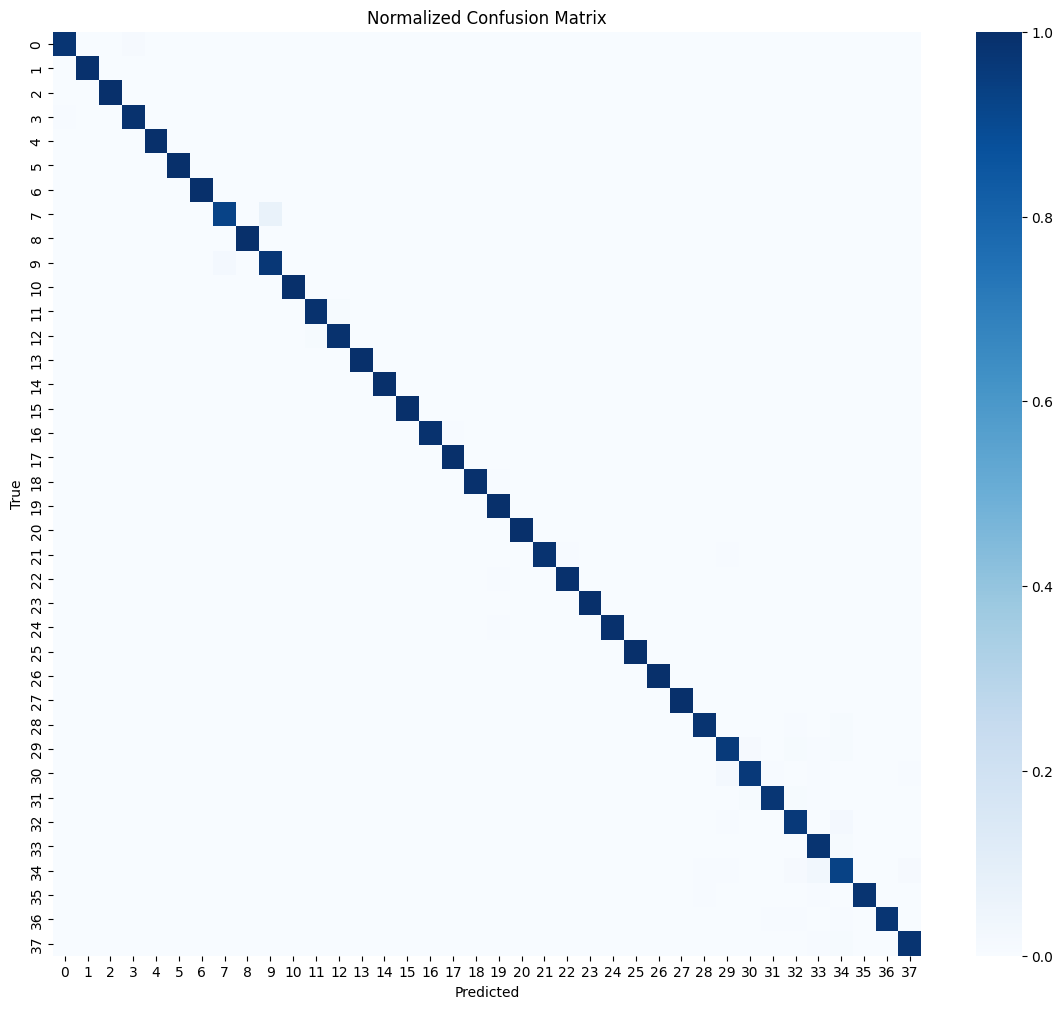

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14,12))
sns.heatmap(cm_norm, cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
